This version of the cnn still has the data augmentation and early stopping but we are going to up the patience from 2 to 4 and lower to augmentation a little bit to see if there is any new results


In [35]:
from pathlib import Path
import pandas as pd
import tensorflow as tf ## deep learning library which will handle loading image tensors, building nn, training the modelm calculating loss, updating weights and making predicitions
import matplotlib.pyplot as plt

load split csv files

In [36]:
PROJECT_ROOT = Path("..")
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

train_df = pd.read_csv(PROCESSED_DIR / "train.csv")
val_df = pd.read_csv(PROCESSED_DIR / "val.csv")
test_df = pd.read_csv(PROCESSED_DIR / "test.csv")

train_df.head()

,original_path,processed_path,label
0,..\data\raw\acne_scars\scar_026.png,..\data\processed\acne_scars\acne_scars_0026.jpg,acne_scars
1,..\data\raw\comedonal_closed\come_022.png,..\data\processed\comedonal_closed\comedonal_c...,comedonal_closed
2,..\data\raw\comedonal_open\comeo_035.png,..\data\processed\comedonal_open\comedonal_ope...,comedonal_open
3,..\data\raw\acne_scars\scar_050.png,..\data\processed\acne_scars\acne_scars_0050.jpg,acne_scars
4,..\data\raw\comedonal_closed\come_021.png,..\data\processed\comedonal_closed\comedonal_c...,comedonal_closed


get class names

In [37]:
class_names = sorted(train_df["label"].unique())
class_names

['acne_scars', 'comedonal_closed', 'comedonal_open', 'inflammatory_acne']

create a label mapping
ie: 0 = class 1 label, 1 = class 2, 2 = class 3, etc

need this since ml models work with numbers instead of text process = label encoding

In [38]:
label_to_index = {label: index for index, label in enumerate(class_names)}
label_to_index

{'acne_scars': 0,
 'comedonal_closed': 1,
 'comedonal_open': 2,
 'inflammatory_acne': 3}

add the numeric labels to dataframes df

In [39]:
train_df["label_index"] = train_df["label"].map(label_to_index)
val_df["label_index"] = val_df["label"].map(label_to_index)
test_df["label_index"] = test_df["label"].map(label_to_index)

train_df.head()

,original_path,processed_path,label,label_index
0,..\data\raw\acne_scars\scar_026.png,..\data\processed\acne_scars\acne_scars_0026.jpg,acne_scars,0
1,..\data\raw\comedonal_closed\come_022.png,..\data\processed\comedonal_closed\comedonal_c...,comedonal_closed,1
2,..\data\raw\comedonal_open\comeo_035.png,..\data\processed\comedonal_open\comedonal_ope...,comedonal_open,2
3,..\data\raw\acne_scars\scar_050.png,..\data\processed\acne_scars\acne_scars_0050.jpg,acne_scars,0
4,..\data\raw\comedonal_closed\come_021.png,..\data\processed\comedonal_closed\comedonal_c...,comedonal_closed,1


ml overview:

in this case the image is the input x and the label is the target y

each row is basically x and y where its image path and numeric class label

In [40]:
train_paths = train_df["processed_path"].values
val_paths = val_df["processed_path"].values
test_paths = test_df["processed_path"].values

train_labels = train_df["label_index"].values
val_labels = val_df["label_index"].values
test_labels = test_df["label_index"].values

image loading function:

essentially tells tf how to turn an image file path into an actual model input

In [41]:
IMG_SIZE = 224

def load_image(image_path, label):
    image = tf.io.read_file(image_path) ## read the file 
    image = tf.image.decode_jpeg(image, channels=3) ## decode the jpeg into a numerical image tensor
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE)) ## resize, safety check, since nn needs consistent input size
    image = image / 255.0 ## normalize to a scale of 0 to 1 instead of 0 to 225 since deep learning models can train better on inputs that are smaller
    
    return image, label

tensorflow datasets:

essentially a way of efficiently handling data, lets tf load images in a structure pipeline

In [42]:
BATCH_SIZE = 16

train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
test_ds = tf.data.Dataset.from_tensor_slices((test_paths, test_labels))

In [43]:
## apply image loading function, basically applies load_image to every item in the dataset
## it chanes image path, label to actual image tensor, label

## before: "../data/processed/acne_scars/acne_scars_0001.jpg", 1
## after: image_array_with_shape_(224,224,3), 1

train_ds = train_ds.map(load_image)
val_ds = val_ds.map(load_image)
test_ds = test_ds.map(load_image)

need to shuffle and batch:

shuffling randomizes the order of training images, this is needed since images are ordered by class and the model could learn in a biased order, so shuffling will give the model a mixed set of examples 

we also only shuffle the training dataset the model learns from it

validation and test data dont need to since we evaluate on them

batching gives the model a group of images instead of one at a time, this done since training one image at a time is slow and noisy and can be memory heavy if training the whole dataset at once 

In [44]:
train_ds = train_ds.shuffle(buffer_size=len(train_df)).batch(BATCH_SIZE)
val_ds = val_ds.batch(BATCH_SIZE)
test_ds = test_ds.batch(BATCH_SIZE)

cnn = convolutional neural network and are desined for images 

the baseline model which used logistic regression flatted images immediately 
224 x 224 x 3 = 150528 pixle features which destroys spatial structure

a cnn keeps the image shape and learns local patterns 

in this case for example it can learn (hopefully it can):
small red regions, clusters of bumps, skin texture changes, edges, dark sports and scar texture

core ideas:

convultional layers, are thee core building block of a cnn, it is what allows the network to detect visual patterns in an image

instead of looking at the whole image at once a CL scans the image with a small grid of numbers called a filter or kernel, it slides across the image patch by patch and doing simple multiplication and sum at each position, the result is a map of where that pattern appears int he image 


note that keras augmentation layers are active duirng training but not during normal evaluation/predictionm

In [45]:
num_classes = len(class_names)

data_augmentation = tf.keras.Sequential([ ## sequential essentially acts as a bucket for your layers
    tf.keras.layers.RandomFlip("horizontal"), ## randomly flips images left to right
    tf.keras.layers.RandomRotation(0.03), ## randomly rotate image slightly (0.05 x 360 degress = 18 degress)
    tf.keras.layers.RandomZoom(0.05), ## randomly zooms image (10%)
])

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(224, 224, 3)), ## each image will have the shape of 224 224 3
    ## first convolution layer, learns 32 small filers, each of size 3 x 3
    ## relu = rectified linear unit helps model learn non-linear patterns
    
    data_augmentation, ## apply the random image transformations during training
    
    tf.keras.layers.Conv2D(32, (3, 3), activation="relu"), 
    tf.keras.layers.MaxPooling2D(), ## reduces image size while keeping important features, makes training faster, reduces memory use, keeps strongest detected patterns, help model focus on important features 

    ## second convulution layer, learns 64 filiters
    ## as the model goes deeper it leanrs more complex patterns
    tf.keras.layers.Conv2D(64, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    ## third convolution layer, learns 128 filters
    tf.keras.layers.Conv2D(128, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(), ## used to turn the visual feature maps into a vector so that the final classification layers can use them

    ## baseline flattened the raw image immediately, cnn flattens only after learning spatial features 

    ## dense layer is a fully connected layer, where it takes the learned image features and starts combining them to make a classification decision
    tf.keras.layers.Dense(128, activation="relu"), 
    tf.keras.layers.Dropout(0.4), ## used to reduce overfitting,0.3 = ignore 30 of this layers neurons

    ## overfitting happens when the model meorizes the training images instead of learn the general patterns

    ## ie: traing accuracy = 90%, validation accuracy = 35% means the model is doing good on images it has seen but bad on new images 

    tf.keras.layers.Dense(num_classes, activation="softmax")
])

compile the model:

tells tf how to train the model it defines, optimizer, loss function and metrics 

optimizer controls how the model update sit weights, during trainign the model makes predictions, checks how wrong it was and then adjusts its weights

loss function measure show wrong the model is, lower loss = better
used spare_categorical_crossentropy LF since there are multiple classes and the labels are integers and not one-hot encoded 

metric tells tf to report accuracy while training

In [46]:

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [47]:
## create early stopping callback
early_stopping = tf.keras.callbacks.EarlyStopping( ## create keras callback which runs during training and can control or monitor the training process 
    monitor="val_loss", ## tells keras to watch val_loss
    patience=4, ## if val loss does not improve for 2 epochs then stop training
    restore_best_weights=True ## after stopping go back to the model from the best validation loss epoch
)

In [48]:
## prints the model architecture such as layers, output shapes and number of parameters

model.summary()


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_4 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,476 (42.61 MB)

 Trainable params: 11,169,476 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

training the model:

for each batch: 
1. Model sees images
2. Model makes predictions
3. TensorFlow compares predictions to true labels
4. Loss is calculated
5. Optimizer updates model weights
6. Repeat

epochs, an epoch means the model has gone through the full training set once so something like epoch = 10 means the model sees the full training dataset 10 times

we also need the validation during training, so after each epoch tf checks the model on val_ds where the validation set helps answer "is the model learning patterns that work on new images, or is it just memorizing training data?"


In [49]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20, ## changed to 20, this is not forcing a specific amount but a specific limit or max
    callbacks=[early_stopping]
)

Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 148ms/step - accuracy: 0.2394 - loss: 1.9642 - val_accuracy: 0.1290 - val_loss: 1.4114
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 139ms/step - accuracy: 0.3380 - loss: 1.3836 - val_accuracy: 0.4194 - val_loss: 1.3235
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 139ms/step - accuracy: 0.4225 - loss: 1.2225 - val_accuracy: 0.4194 - val_loss: 1.2834
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 136ms/step - accuracy: 0.4155 - loss: 1.2352 - val_accuracy: 0.4516 - val_loss: 1.2764
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 128ms/step - accuracy: 0.3732 - loss: 1.2258 - val_accuracy: 0.3871 - val_loss: 1.3201
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 130ms/step - accuracy: 0.4366 - loss: 1.2182 - val_accuracy: 0.3226 - val_loss: 1.4042
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 130ms/step - accuracy: 0.3803 - loss: 1.1711 - val_accuracy: 0.4194 - val_loss: 1.5011
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 126ms/step - accuracy: 0.4366 - loss: 1.2174 - val_accuracy: 0.3871 - val_loss:

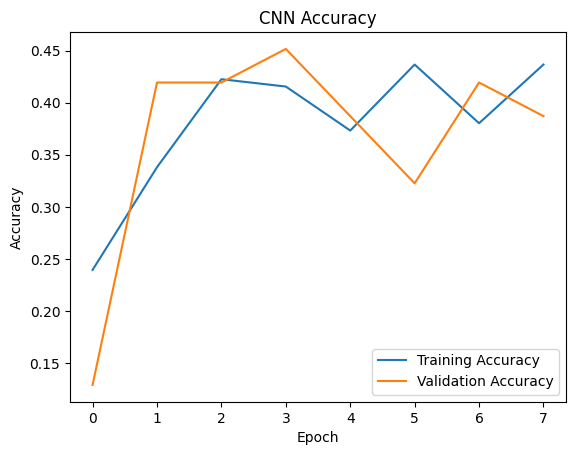

In [50]:
## accuracy plot shows accuracy of training and validation:

## good: training accuracy increases, validation accuracy also increases

## overfitting: training accuracy keeps increasing, validation accuracy stops improving or decreases = model is memorizing training data

## underfitting: training accuracy low, validation accuracy low = means the model is not learning enough
## which could be from the model being to simple, not enough epochs, and more


plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

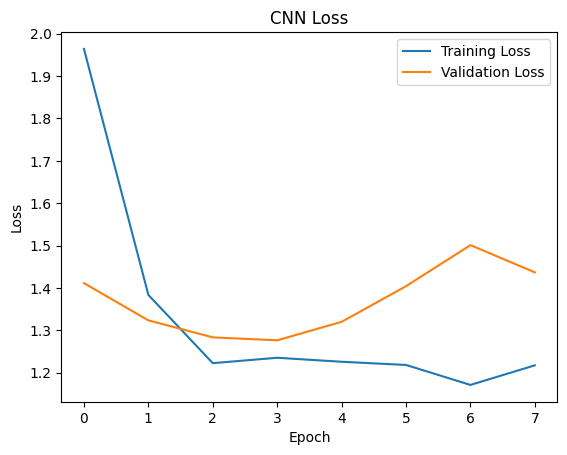

In [51]:
## loss plot

## good: training loss decreases, validation loss decreases

## overfitting: training loss decreases, validation loss increases 

## unstable training: loss jumps up and down a lot 
## due to small dataset, batch size too small, data too noisy 

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()